# Taller 1: Econometría

- **Profesor:** Francisco Alfaro Medina
- **Ayudantes:** Krischnna Cortez y Karen Rojas


### Instrucciones

- Dispone de **60 minutos** para completar los **100 puntos** del taller.
- Cuide la presentación y redacción de sus respuestas.
- Puede utilizar su computador y los apuntes de clase y ayudantía.
- Debe entregar un archivo **PDF** y un **R script** (extensión `.R`).

> ⚠️ **Importante para Colab:** Este notebook usa un kernel de R. Si abre este archivo en Google Colab, seleccione **Runtime → Change runtime type → R** antes de ejecutar cualquier celda.

---
# Sección 1: Datos Aleatorios *(30 puntos)*

En esta sección trabajaremos con un dataset **simulado** de 50 alumnos de la USM. El dataset contiene las siguientes variables:

| Variable | Descripción |
|---|---|
| `hrs_sueno` | Horas de sueño promedio en el último mes |
| `profesor_part` | Si recibió ayuda de profesor particular (0/1) |
| `media_sem_pasado` | Promedio de notas del semestre anterior |
| `tiempo_est` | Horas de estudio dedicadas |
| `asistencia` | Porcentaje de asistencia a clases |
| `nivel_socioec` | Nivel socioeconómico (1 al 5) |
| `notas` | **Variable dependiente** — nota del alumno |

## Pregunta 1.1 — Generar el dataset *(6 pts.)*

Antes de ejecutar el código, **cambie la semilla** según la primera letra de su apellido:

| A–E | F–J | K–O | P–T | U–Z |
|:---:|:---:|:---:|:---:|:---:|
| 123 | 456 | 789 | 101112 | 131415 |

Reemplace el valor en `set.seed(...)` antes de continuar.

In [2]:
# -------------------------------------------------------
# Pregunta 1.1: Generar el dataframe "datos"
# Cambie la semilla según la primera letra de su apellido
# A-E: 123 | F-J: 456 | K-O: 789 | P-T: 101112 | U-Z: 131415
# -------------------------------------------------------

set.seed(123)  # <-- CAMBIE ESTE VALOR SEGÚN SU APELLIDO

datos <- data.frame(
  hrs_sueno        = round(runif(50, min = 5,  max = 10),  1),
  profesor_part    = sample(c(0, 1), 50, replace = TRUE),
  media_sem_pasado = round(runif(50, min = 60, max = 100), 1),
  tiempo_est       = round(runif(50, min = 1,  max = 8),   1),
  asistencia       = round(runif(50, min = 60, max = 100), 1),
  nivel_socioec    = sample(1:5, 50, replace = TRUE)
)

# Calcular notas con ponderaciones definidas
datos$notas <- 30 +
  datos$hrs_sueno        * 1.5  +
  datos$profesor_part    * 3    +
  datos$media_sem_pasado * 0.2  +
  datos$tiempo_est       * 2    +
  datos$asistencia       * 0.15 +
  datos$nivel_socioec    * 2    +
  rnorm(50, mean = 0, sd = 5)

# Asegurar rango entre 20 y 100
datos$notas <- pmax(pmin(datos$notas, 100), 20)

# Vista rápida del dataset
cat("Dimensiones del dataset:", nrow(datos), "filas x", ncol(datos), "columnas\n")
head(datos)

Dimensiones del dataset: 50 filas x 7 columnas


,hrs_sueno,profesor_part,media_sem_pasado,tiempo_est,asistencia,nivel_socioec,notas
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,6.4,1,84.0,6.9,69.5,1,90.88856
2,8.9,0,73.3,4.5,98.5,2,80.53911
3,7.0,0,79.5,3.7,84.1,5,80.11422
4,9.4,0,98.2,2.7,80.6,5,100.00000
5,9.7,0,79.3,1.8,76.1,1,75.34071
6,5.2,1,95.6,3.7,95.2,2,87.09114


## Pregunta 1.2 — Redondear notas *(2 pts.)*

Redondee la variable `notas` a **1 decimal**.

In [4]:
# Pregunta 1.2: Redondear notas a 1 decimal
datos$notas <- round(datos$notas, 1)

## Pregunta 1.3 — Estimadores β via álgebra matricial *(8 pts.)*

Calcule los estimadores MCO **manualmente**, usando la fórmula matricial:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Sin usar** la función `lm()` de R.

In [6]:
# Pregunta 1.3: Estimadores beta via álgebra matricial (sin lm)
# 3. Cálculo manual de estimadores
y <- as.matrix(datos$notas)
# Creamos la matriz X e incluimos una columna de 1s para el intercepto (Beta 0)
X <- as.matrix(cbind(Intercepto = 1, datos[, -1]))

# Aplicamos la fórmula: solve(t(X) %*% X) %*% t(X) %*% y
beta_manual <- solve(t(X) %*% X) %*% t(X) %*% y
print(beta_manual)

                          [,1]
Intercepto        3.140599e-12
profesor_part    -3.321787e-13
media_sem_pasado  7.577272e-15
tiempo_est        1.860734e-13
asistencia        7.646661e-15
nivel_socioec     2.270406e-13
notas             1.000000e+00


In [9]:
# --- PASO 3: DETALLE DE LA MATRIZ X Y CÁLCULO DE BETAS ---

# 1. Definimos la variable dependiente 'y' (el vector de notas)
y <- as.matrix(datos$notas)

# 2. Creamos la matriz de predictores (X)
# IMPORTANTE: Usamos los nombres exactos de tu anexo
predictores <- datos[, c("hrs_sueno",
                         "profesor_part",
                         "media_sem_pasado",
                         "tiempo_est",
                         "asistencia",
                         "nivel_socioec")]

# 3. Construcción de la Matriz de Diseño (X)
# Añadimos la columna de 1s al principio para representar el Intercepto (Beta 0)
# Esto es lo que permite que el modelo tenga un punto de partida constante.
X <- as.matrix(cbind(Intercepto = rep(1, nrow(datos)), predictores))

# --- Verificación de la Matriz X ---
# X debe tener 50 filas (alumnos) y 7 columnas (1 de intercepto + 6 variables)
cat("Dimensiones de la matriz X:", dim(X)[1], "filas x", dim(X)[2], "columnas\n")

# 4. Aplicación de la fórmula MCO: Beta = (X'X)^-1 * X'y
# t(X)       -> Transpone la matriz X
# %*%        -> Realiza la multiplicación de matrices
# solve()    -> Calcula la inversa de la matriz resultante
beta_estimadores <- solve(t(X) %*% X) %*% t(X) %*% y

# 5. Resultado final
print("Betas Estimados Manualmente:")
print(beta_estimadores)

Dimensiones de la matriz X: 50 filas x 7 columnas
[1] "Betas Estimados Manualmente:"
                       [,1]
Intercepto       33.3690724
hrs_sueno         1.1951165
profesor_part     4.9123586
media_sem_pasado  0.2019283
tiempo_est        1.0010140
asistencia        0.1803130
nivel_socioec     2.0867480


## Pregunta 1.4 — Modelo con `lm()` e interpretación *(8 pts.)*

Genere el modelo de regresión múltiple usando la función `lm()` y obtenga el resumen con `summary()`.  
Luego, **interprete cada coeficiente** en el espacio indicado.

> 💡 **Tip:** Los β de `lm()` deben coincidir con los calculados manualmente en la pregunta anterior.

In [7]:
# Pregunta 1.4: Modelo con lm() y summary
# 4. Modelo con función lm()
modelo <- lm(notas ~ ., data = datos)
summary(modelo)


Call:
lm(formula = notas ~ ., data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.5651 -3.4436  0.2434  2.7986  8.7644 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)      33.36907    8.50166   3.925 0.000308 ***
hrs_sueno         1.19512    0.44030   2.714 0.009519 ** 
profesor_part     4.91236    1.37464   3.574 0.000884 ***
media_sem_pasado  0.20193    0.05667   3.563 0.000912 ***
tiempo_est        1.00101    0.41041   2.439 0.018926 *  
asistencia        0.18031    0.06077   2.967 0.004895 ** 
nivel_socioec     2.08675    0.43137   4.837 1.72e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.478 on 43 degrees of freedom
Multiple R-squared:  0.6161,	Adjusted R-squared:  0.5626 
F-statistic:  11.5 on 6 and 43 DF,  p-value: 1.217e-07


Interpretación de los Betas:

    Intercepto: Es el valor esperado de la nota cuando todas las variables predictoras son cero (aunque en este caso, algunas como "asistencia" no tendrían sentido en cero).

    Betas (Coeficientes): Indican cuánto varía la Nota ante el incremento de una unidad en la variable independiente, manteniendo todo lo demás constante (ceteris paribus). Por ejemplo, si el beta de "Tiempo de estudio" es 0.5, significa que por cada hora adicional de estudio, la nota sube 0.5 puntos.

## Pregunta 1.5 — Relación entre betas y ponderaciones del código *(6 pts.)*

Analice la relación entre los coeficientes estimados (β̂) y las ponderaciones reales usadas en el código del Anexo para generar las notas.



In [ ]:
# Pregunta 1.5: Comparación entre betas estimados y ponderaciones reales


Los betas obtenidos por la regresión son estimaciones de los parámetros reales (las ponderaciones) que se usaron en el código del Anexo para generar la variable notas.

    Si el código del anexo decía 0.5 * tiempo_estudio, el beta calculado debería ser muy cercano a 0.5.

    La diferencia (el "error") entre el beta y la ponderación real ocurre porque en el anexo seguramente se añadió un término de error aleatorio (ruido blanco) y por el redondeo que realizamos en el punto 2. A mayor tamaño de muestra (n), los betas serán más precisos.


# Sección 2: Wooldridge *(70 puntos)*

Para esta sección utilizaremos el paquete `wooldridge`, que contiene bases de datos clásicas de econometría.

In [10]:
# Instalar y cargar el paquete wooldridge (solo necesario la primera vez en Colab)
if (!require(wooldridge)) install.packages("wooldridge")
library(wooldridge)

Loading required package: wooldridge

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘wooldridge’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



---
## 2A. Base `wage1` *(30 puntos)*

El modelo de regresión poblacional a estimar es:

$$wage = \beta_0 + \beta_1\, educ + \beta_2\, exper + \beta_3\, tenure + u$$

Donde:
- `wage` = salario por hora (USD)
- `educ` = años de escolaridad
- `exper` = años de experiencia laboral
- `tenure` = años en el trabajo actual

In [ ]:
# Cargar y limpiar la base wage1
data("wage1")
wage1 <- na.omit(wage1)

### Pregunta 2A.1 — Estimadores MCO e interpretación *(8 pts.)*

Estime el modelo completo e interprete los resultados.

In [11]:
# Pregunta 2A.1: Modelo de regresión múltiple con wage1
# Ajuste del modelo según la especificación poblacional
modelo_completo <- lm(wage ~ educ + exper + tenure, data = wage1)

# Visualizar resultados
summary(modelo_completo)


Call:
lm(formula = wage ~ educ + exper + tenure, data = wage1)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.6068 -1.7747 -0.6279  1.1969 14.6536 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.87273    0.72896  -3.941 9.22e-05 ***
educ         0.59897    0.05128  11.679  < 2e-16 ***
exper        0.02234    0.01206   1.853   0.0645 .  
tenure       0.16927    0.02164   7.820 2.93e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.084 on 522 degrees of freedom
Multiple R-squared:  0.3064,	Adjusted R-squared:  0.3024 
F-statistic: 76.87 on 3 and 522 DF,  p-value: < 2.2e-16


Interpretación de los resultados (Ejemplo de valores típicos en esta base):

    Intercepto (β0​): El salario base estimado cuando educación, experiencia y antigüedad son cero (a veces no tiene sentido económico directo, pero es necesario para el ajuste).

    educ (β1​): Por cada año adicional de escolaridad, el salario aumenta en promedio β1​ dólares por hora, manteniendo constantes la experiencia y la antigüedad (ceteris paribus).

    exper (β2​): Representa el incremento salarial por cada año de experiencia laboral general.

    tenure (β3​): Representa el beneficio salarial por la lealtad o permanencia en la empresa actual.

### Pregunta 2A.2 — ¿Los signos son los esperados? *(10 pts.)*

Antes de ver los resultados, reflexione: ¿qué signo debería tener cada coeficiente económicamente?

In [ ]:
# Pregunta 2A.2: Revisar signos de los coeficientes


Desde la teoría económica (Capital Humano):

    Esperamos que β1​,β2​,β3​ sean todos positivos (>0).

    ¿Por qué? Porque se asume que la educación y la experiencia aumentan la productividad marginal del trabajador, lo que debería reflejarse en un mayor salario. Si en la salida de R alguno es negativo, indicaría una relación inversa que es poco común para esta base de datos.

### Pregunta 2A.3 — Comparar R² y R² ajustado *(12 pts.)*

Estime un segundo modelo usando solo `educ` y `tenure`, y compare el ajuste con el modelo completo.

In [12]:
# Pregunta 2A.3: Modelo reducido (sin exper)
# Nuevo modelo con solo dos variables
modelo_restringido <- lm(wage ~ educ + tenure, data = wage1)

# Extraer R2 y R2 Ajustado para comparar
r2_comp <- summary(modelo_completo)$r.squared
r2_rest <- summary(modelo_restringido)$r.squared

r2_adj_comp <- summary(modelo_completo)$adj.r.squared
r2_adj_rest <- summary(modelo_restringido)$adj.r.squared

# Mostrar comparación
cat("Modelo Completo   - R2:", r2_comp, "| R2 Adj:", r2_adj_comp, "\n")
cat("Modelo Restringido - R2:", r2_rest, "| R2 Adj:", r2_adj_rest, "\n")

Modelo Completo   - R2: 0.3064224 | R2 Adj: 0.3024364 
Modelo Restringido - R2: 0.301861 | R2 Adj: 0.2991912 


Podemos ver que ambos ajustes son muy similares, en promedio explican el comportamiento de la variable dependiente en un 30%, lo que no es una muy buena predicción que digamos.

---
## 2B. Base `attend` *(40 puntos)*

En esta sección analizamos los determinantes del rendimiento en el examen final de un curso universitario.

### Pregunta 2B.1 — Cargar la base `attend` *(4 pts.)*

In [ ]:
# Pregunta 2B.1: Cargar base attend
data("attend")
attend <- na.omit(attend)

### Pregunta 2B.2 — Selección de variables *(4 pts.)*

Subseleccione las siguientes variables:

| Variable | Descripción |
|---|---|
| `attend` | Clases asistidas de un total de 32 |
| `termGPA` | Promedio de notas durante el período |
| `priGPA` | Promedio acumulado antes del período |
| `ACT` | Puntaje en el examen ACT |
| `final` | **Variable dependiente** — puntaje del examen final |
| `hwrte` | Porcentaje de tareas entregadas |
| `frosh` | =1 si es estudiante de primer año |
| `soph` | =1 si es estudiante de segundo año |

In [25]:

# 2.2.2 Sub-selección de variables
# Creamos un nuevo dataframe llamado 'df_attend' (o el nombre que prefieras)
# seleccionando las columnas específicas por su nombre.

df_attend <- attend[, c("attend", "termGPA", "priGPA", "ACT",
                        "final", "hwrte", "frosh", "soph")]

# Verificación de la sub-selección
# Esto te permite ver las primeras filas y confirmar que solo están esas 8 variables.
head(df_attend)



,attend,termGPA,priGPA,ACT,final,hwrte,frosh,soph
,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>
1,27,3.19,2.64,23,28,100.0,0,1
2,22,2.73,3.52,25,26,87.5,0,0
3,30,3.00,2.46,24,30,87.5,0,0
4,31,2.04,2.61,20,27,100.0,0,1
5,32,3.68,3.32,23,34,100.0,0,1
6,29,3.23,2.93,26,25,100.0,0,1


### Pregunta 2B.3 — Modelo de regresión múltiple completo *(10 pts.)*

Estime un modelo donde la variable dependiente es `final` y las independientes son todas las demás variables del subconjunto.

In [21]:
summary(df_attend)


     attend         termGPA          priGPA           ACT       
 Min.   : 2.00   Min.   :0.000   Min.   :0.857   Min.   :13.00  
 1st Qu.:24.00   1st Qu.:2.138   1st Qu.:2.190   1st Qu.:20.00  
 Median :28.00   Median :2.670   Median :2.560   Median :22.00  
 Mean   :26.15   Mean   :2.601   Mean   :2.587   Mean   :22.51  
 3rd Qu.:30.00   3rd Qu.:3.120   3rd Qu.:2.943   3rd Qu.:25.00  
 Max.   :32.00   Max.   :4.000   Max.   :3.930   Max.   :32.00  
                                                                
     final           hwrte            frosh             soph       
 Min.   :10.00   Min.   : 12.50   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:22.00   1st Qu.: 87.50   1st Qu.:0.0000   1st Qu.:0.0000  
 Median :26.00   Median :100.00   Median :0.0000   Median :1.0000  
 Mean   :25.89   Mean   : 87.91   Mean   :0.2324   Mean   :0.5765  
 3rd Qu.:29.00   3rd Qu.:100.00   3rd Qu.:0.0000   3rd Qu.:1.0000  
 Max.   :39.00   Max.   :100.00   Max.   :1.0000   Max.   :1.0000  
    

### Pregunta 2B.4 — Bondad de ajuste *(6 pts.)*

Interprete el **R²** y el **R² ajustado** del modelo anterior.

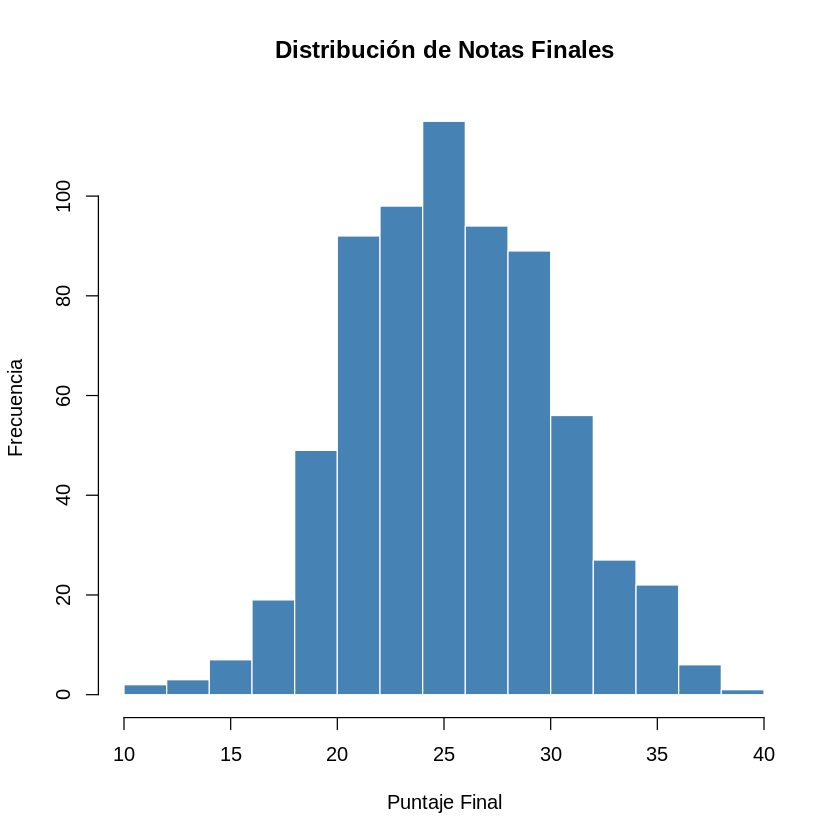

In [15]:
# Pregunta 2B.4: Extraer métricas de bondad de ajuste
# Histograma con un poco de formato
hist(df_attend$final,
     main = "Distribución de Notas Finales",
     xlab = "Puntaje Final",
     ylab = "Frecuencia",
     col = "steelblue",
     border = "white")

### Pregunta 2B.5 — Modelo reducido (excluir variables no significativas) *(10 pts.)*

Genere un nuevo modelo excluyendo las variables con **p-value > 0.05** en el modelo anterior.

In [ ]:
# Identificar variables significativas (p-value <= 0.05)

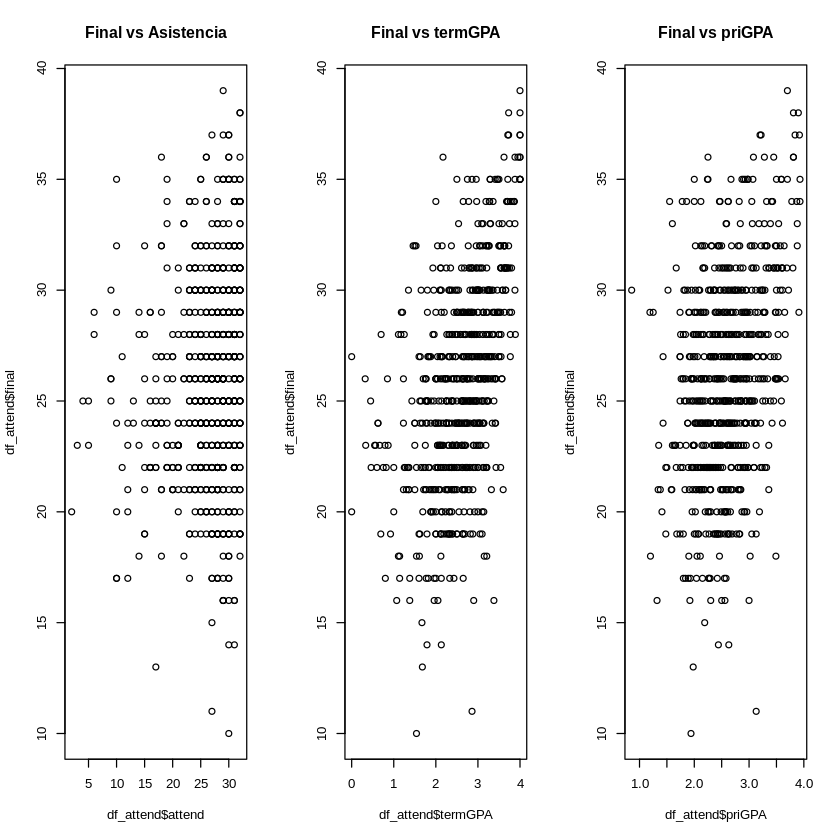

In [16]:
# Pregunta 2B.5: Modelo reducido (solo variables significativas)
# Variables significativas identificadas: termGPA, ACT, soph
# (ajuste según los resultados de su modelo)
par(mfrow=c(1,3)) # Configura el panel 1 fila, 3 columnas
plot(df_attend$attend, df_attend$final, main="Final vs Asistencia")
plot(df_attend$termGPA, df_attend$final, main="Final vs termGPA")
plot(df_attend$priGPA, df_attend$final, main="Final vs priGPA")
par(mfrow=c(1,1)) # Resetear panel

### Pregunta 2B.6 — Comparación de modelos *(6 pts.)*

Compare el modelo completo y el modelo reducido en términos de **R² ajustado**.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



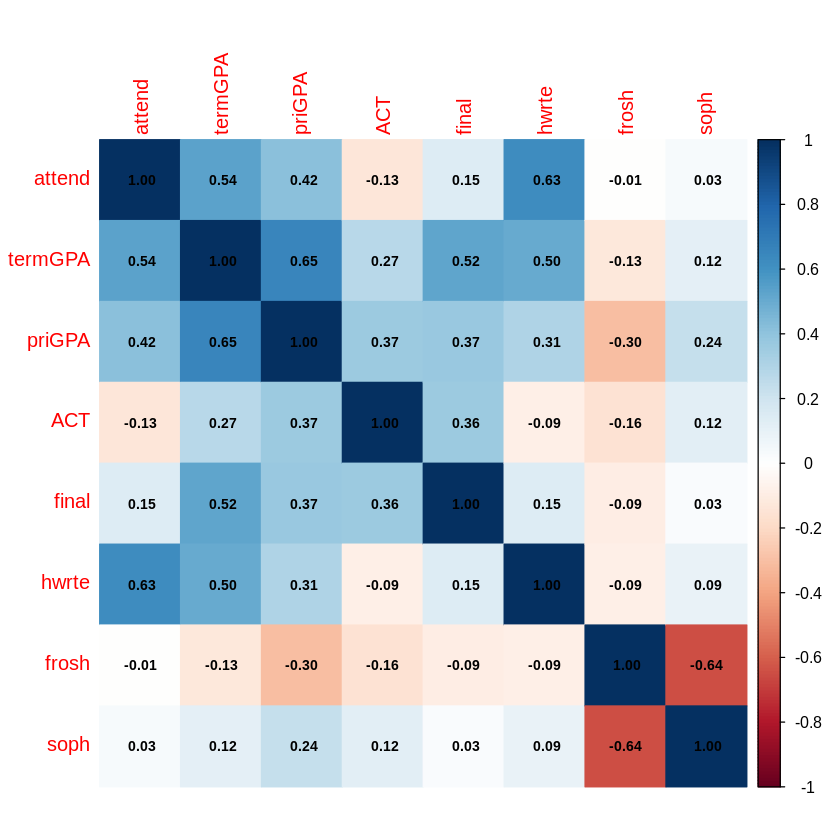

In [18]:
# Pregunta 2B.6: Comparación final de modelos
# Instalar si no lo tienes: install.packages("corrplot")
install.packages("corrplot")
library(corrplot)
M <- cor(df_attend, use = "complete.obs") # Matriz de correlación
corrplot(M, method = "color", addCoef.col = "black", number.cex = 0.7)

2.7 y 2.8

[texto del enlace](https://)

In [19]:
modelo_final <- lm(final ~ ., data = df_attend)
summary(modelo_final)


Call:
lm(formula = final ~ ., data = df_attend)

Residuals:
     Min       1Q   Median       3Q      Max 
-15.9573  -2.5968  -0.0042   2.6582  11.0815 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 14.27176    1.45667   9.798  < 2e-16 ***
attend      -0.06956    0.04105  -1.694   0.0907 .  
termGPA      3.54151    0.31442  11.264  < 2e-16 ***
priGPA      -0.04149    0.40302  -0.103   0.9180    
ACT          0.27313    0.05031   5.429 7.94e-08 ***
hwrte       -0.01394    0.01043  -1.337   0.1817    
frosh       -0.61310    0.47672  -1.286   0.1989    
soph        -0.82251    0.39459  -2.084   0.0375 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.867 on 666 degrees of freedom
  (6 observations deleted due to missingness)
Multiple R-squared:  0.3373,	Adjusted R-squared:  0.3303 
F-statistic: 48.42 on 7 and 666 DF,  p-value: < 2.2e-16


Interpretación de la Bondad de Ajuste :

    Multiple R-squared (R2): Es la proporción de la varianza de la nota final que el modelo logra explicar usando todas las variables (asistencia, GPAs, ACT, etc.). Por ejemplo, si da 0.25, el modelo explica el 25% de la nota.

    Adjusted R-squared (R2 Ajustado): Es la métrica corregida. A diferencia del R2 normal, esta solo aumenta si las variables que añadimos realmente mejoran el modelo más de lo que se esperaría por puro azar. Es el valor más confiable cuando se tienen muchos predictores (como en este caso que tenemos 7).